# Moving Average Crossover Strategy
## Objective:
Investigate whether a moving average crossover strategy can outperform buy-and-hold after transaction costs and whether any performance survives out-of-sample testing.

## Imports
Import the libraries required for data collection, analysis and visualisation.

In [3]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Data Collection and Signal Generation

Download historical market data and generate trading signals based on moving average crossovers.

In [6]:
def get_data(ticker, start, end):
    """Download daily adjusted stock price data from Yahoo Finance."""
    data = yf.download(ticker, start=start, end=end, interval='1d', auto_adjust=True, progress=False)
    return data.dropna()

def add_signals(data, short_ma=20, long_ma=50):
    """Generate moving average crossover trading signals."""
    data['Return'] = data['Close'].pct_change()
    data['Short_MA'] = data['Close'].rolling(short_ma).mean()
    data['Long_MA'] = data['Close'].rolling(long_ma).mean()
    data['Signal'] = data['Short_MA'] > data['Long_MA']
    data['Position'] = data['Signal'].shift(1, fill_value=False).astype(int)
    return data

## Performance Metrics

The following functions evaluate strategy performance using:

- Total return
- Sharpe ratio
- Maximum drawdown

In [9]:
def calculate_drawdown(equity_curve):
    """Calculate the maximum drawdown of an equity curve."""
    drawdown = (equity_curve - equity_curve.cummax()) / equity_curve.cummax()
    return drawdown.min()

def calculate_sharpe(returns):
    """Calculate the annualised Sharpe ratio using 252 trading days."""
    returns = returns.dropna()
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(252)

## Backtesting Framework

Simulate trades, apply transaction costs and compare strategy performance against buy-and-hold.

In [12]:
def backtest(ticker, start, end, short_ma=20, long_ma=50, cost=0.001):
    """Run a moving average crossover backtest and return performance metrics."""
    data = get_data(ticker, start, end)
    data = add_signals(data, short_ma, long_ma)
    data['Trade'] = data['Position'].diff().fillna(0)
    data['Cost'] = (data['Trade'].abs()) * cost
    data['Strategy_Return_Net'] = data['Return'] * data['Position'] - data['Cost']
    data['Buy_Hold_Equity'] = (1 + data['Return']).cumprod()
    data['Strategy_Equity'] = (1 + data['Strategy_Return_Net']).cumprod()
    results = {
        'Ticker': ticker,
        'Short_MA': short_ma,
        'Long_MA': long_ma,
        'Buy_Hold_Return_%': (data['Buy_Hold_Equity'].iloc[-1]-1) * 100,
        'Strategy_Return_%': (data['Strategy_Equity'].iloc[-1]-1) * 100,
        'Buy_Hold_Max_Drawdown': calculate_drawdown(data['Buy_Hold_Equity']) * 100,
        'Strategy_Max_Drawdown': calculate_drawdown(data['Strategy_Equity']) * 100,
        'Buy_Hold_Sharpe': calculate_sharpe(data['Return']),
        'Strategy_Sharpe': calculate_sharpe(data['Strategy_Return_Net']),
        'Trades': (data['Trade'].abs()).sum(),
        'Outperformance_%': ((data['Strategy_Equity'].iloc[-1]-1) * 100
                          - (data['Buy_Hold_Equity'].iloc[-1]-1) * 100)
    }
    return results, data

## Parameter Optimisation

Test multiple moving average combinations across several assets and identify the strongest-performing parameter sets.

In [15]:
def optimise_all(tickers, start, end, short_ma_values, long_ma_values, cost=0.001):
    """Evaluate all moving average parameter combinations across multiple assets."""
    all_results = []
    for ticker in tickers:
        for short_ma in short_ma_values:
            for long_ma in long_ma_values:
                if short_ma >= long_ma:
                    continue
                results, data = backtest(ticker, start, end, short_ma, long_ma, cost)
                all_results.append(results)
    return pd.DataFrame(all_results)

## Train-Test Validation

Parameters are selected using training data and then evaluated on unseen test data to reduce the risk of overfitting.

In [18]:
def train_test_optimise(tickers, train_start, train_end, test_start, test_end,
                        short_ma_values, long_ma_values, cost=0.001):
    """Optimise parameters on training data and evaluate on unseen test data."""
    
    train_results = optimise_all(
        tickers, train_start, train_end,
        short_ma_values, long_ma_values, cost)
    
    best_params = (
        train_results
        .sort_values('Strategy_Sharpe', ascending=False)
        .groupby('Ticker')
        .head(1))
    
    test_results = []
    
    for _, row in best_params.iterrows():
        ticker = row['Ticker']
        short_ma = int(row['Short_MA'])
        long_ma = int(row['Long_MA'])
        
        results, data = backtest(
            ticker, test_start, test_end,
            short_ma, long_ma, cost)
        
        results['Train_Sharpe'] = row['Strategy_Sharpe']
        results['Sharpe_Difference'] = results['Strategy_Sharpe'] - row['Strategy_Sharpe']
        results['Robust_Score'] = results['Strategy_Sharpe'] - abs(results['Sharpe_Difference'])
        test_results.append(results)
    
    return best_params, pd.DataFrame(test_results)

tickers = [
    'AAPL', 'RACE', 'NVDA', 'TSLA', 'VTI', 'MSFT', 'GOOGL', 
    'META', 'AMZN', 'JPM', 'KO', 'WMT', 'XOM'
]

A custom metric was introduced to identify strategies that performed well both in-sample and out-of-sample.

The Robust Score is defined as:

`Robust Score = Test Sharpe - abs(Test Sharpe - Train Sharpe)`

The intuition is that a strategy should not only achieve a high out-of-sample Sharpe ratio, but should also maintain performance similar to that observed during training.

Strategies with large performance deterioration between the training and testing periods are penalised, while those that maintain performance receive higher scores.

This is not a standard industry metric, but rather a simple measure designed for this project to combine out-of-sample performance with consistency between the training and testing datasets.

## Experimental Setup

In [22]:
short_ma_values = [5, 10, 20, 30, 50]
long_ma_values = [50, 100, 150, 200]

best_train, test_results = train_test_optimise(
    tickers,
    '2015-01-01',  # train start
    '2022-01-01',  # train end
    '2022-01-01',  # test start
    '2025-01-01',  # test end
    short_ma_values,
    long_ma_values,
    cost=0.001)

## Results

The table below shows the best parameter combinations identified during training and their subsequent out-of-sample performance.

In [24]:
print("BEST TRAINING PARAMETERS")
display(best_train)

BEST TRAINING PARAMETERS


,Ticker,Short_MA,Long_MA,Buy_Hold_Return_%,Strategy_Return_%,Buy_Hold_Max_Drawdown,Strategy_Max_Drawdown,Buy_Hold_Sharpe,Strategy_Sharpe,Trades,Outperformance_%
55,NVDA,50,150,5977.317642,5867.735705,-56.038455,-45.118004,1.518190,1.633607,5.0,-109.581937
36,RACE,50,150,394.879847,475.936732,-43.612328,-27.838848,1.000325,1.310715,9.0,81.056885
0,AAPL,5,50,617.570657,368.760163,-38.515904,-25.043497,1.116920,1.213023,49.0,-248.810494
106,MSFT,20,200,716.432623,563.343015,-28.039264,-28.039264,1.249388,1.206477,5.0,-153.089608
73,TSLA,50,100,2309.329196,2008.760619,-60.626539,-60.626539,1.101067,1.161785,19.0,-300.568577
152,AMZN,5,50,980.753268,387.085020,-34.103783,-38.570342,1.280722,1.123282,48.0,-593.668248
78,VTI,5,150,158.789601,115.299570,-35.000289,-13.691420,0.846568,1.005524,21.0,-43.490031
183,JPM,30,50,205.146179,184.878975,-43.626486,-18.961006,0.704639,0.888874,32.0,-20.267204
122,GOOGL,20,50,447.075813,192.705377,-30.870821,-22.166334,1.050912,0.869187,35.0,-254.370436
141,META,20,50,328.744338,206.124553,-42.960922,-21.679401,0.819011,0.820746,32.0,-122.619785


In [25]:
print("\nOUT OF SAMPLE RESULTS")
display(test_results.sort_values('Robust_Score', ascending=False))


OUT OF SAMPLE RESULTS


,Ticker,Short_MA,Long_MA,Buy_Hold_Return_%,Strategy_Return_%,Buy_Hold_Max_Drawdown,Strategy_Max_Drawdown,Buy_Hold_Sharpe,Strategy_Sharpe,Trades,Outperformance_%,Train_Sharpe,Sharpe_Difference,Robust_Score
0,NVDA,50,150,346.576505,803.559363,-61.643488,-27.046766,1.180090,1.992320,1.0,456.982857,1.633607,0.358713,1.633607
1,RACE,50,150,67.071410,85.181319,-36.891497,-14.887583,0.747135,1.086334,3.0,18.109909,1.310715,-0.224382,0.861952
9,META,20,50,73.612131,211.076462,-73.580367,-27.953803,0.627110,1.298835,13.0,137.464331,0.820746,0.478089,0.820746
7,JPM,30,50,61.241645,47.928032,-37.929550,-15.300783,0.765091,0.836749,11.0,-13.313613,0.888874,-0.052125,0.784624
6,VTI,5,150,24.800082,29.049788,-25.221740,-11.941421,0.502505,0.830832,11.0,4.249706,1.005524,-0.174692,0.656139
10,WMT,10,100,95.548025,88.750876,-25.739672,-9.484749,1.194066,1.468083,5.0,-6.797148,0.640606,0.827477,0.640606
5,AMZN,5,50,28.746603,67.440261,-51.675871,-19.940703,0.412371,0.832036,19.0,38.693658,1.123282,-0.291246,0.540790
3,MSFT,20,200,29.180462,42.064010,-34.454928,-18.898424,0.448897,0.777215,9.0,12.883548,1.206477,-0.429262,0.347953
4,TSLA,50,100,0.978512,70.201494,-71.789942,-38.273927,0.310292,0.653719,9.0,69.222983,1.161785,-0.508066,0.145653
2,AAPL,5,50,39.839595,25.616059,-30.024735,-23.080686,0.549817,0.551275,23.0,-14.223536,1.213023,-0.661747,-0.110472


## Visualisation

Example strategy signals and equity curves for selected assets.

In [27]:
def plot_backtest(ticker, start, end, short_ma=20, long_ma=50, cost=0.001):
    """Visualise price data, moving averages and generated trading signals."""
    results, data = backtest(ticker, start, end, short_ma, long_ma, cost)
    buys = data[data['Position'].diff() == 1]
    sells = data[data['Position'].diff() == -1]
    
    plt.figure(figsize=(12, 4))
    plt.plot(data.index, data['Close'], label='Close', color='black', lw=1)
    plt.plot(data.index, data['Short_MA'], label=f'{short_ma} MA')
    plt.plot(data.index, data['Long_MA'], label=f'{long_ma} MA')
    plt.scatter(buys.index, buys['Close'], marker='^', color='green', s=100, label='Buy')
    plt.scatter(sells.index, sells['Close'], marker='v', color='red', s=100, label='Sell')
    plt.title(ticker)
    plt.grid()
    plt.legend()
    plt.show()

def plot_equity_curve(ticker, start, end, short_ma=20, long_ma=50, cost=0.001):
    """Compare strategy and buy-and-hold cumulative returns."""
    results, data = backtest(ticker, start, end, short_ma, long_ma, cost)
    plt.figure(figsize=(12, 4))
    plt.plot(data.index, data['Buy_Hold_Equity'], label='Buy & Hold', color='pink')
    plt.plot(data.index, data['Strategy_Equity'], label='Strategy')
    plt.title(f'{ticker} Equity Curve')
    plt.grid()
    plt.legend()
    plt.show()

### Example: NVIDIA (Out-of-Sample Test Period)

The 50/150 moving average combination was selected using training data from 2015–2022 and then evaluated on unseen data from 2022–2025.

NVIDIA was selected as an example because it achieved one of the strongest Robust Scores in the out-of-sample results.

This visualisation illustrates how buy and sell signals are generated by moving average crossovers.

A longer time period is shown to better demonstrate the strategy's trading behaviour and signal generation process.

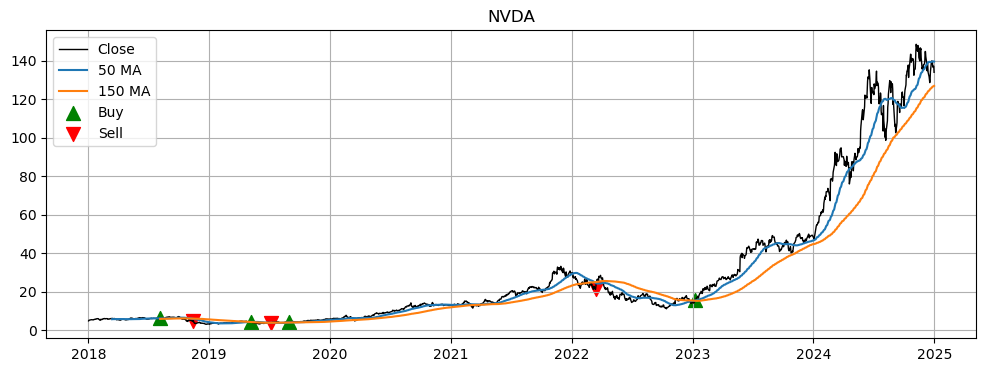

In [29]:
plot_backtest("NVDA", "2018-01-01", "2025-01-01", 50, 150)

The equity curve below compares the cumulative performance of the moving average strategy with a buy-and-hold approach during the same out-of-sample period.

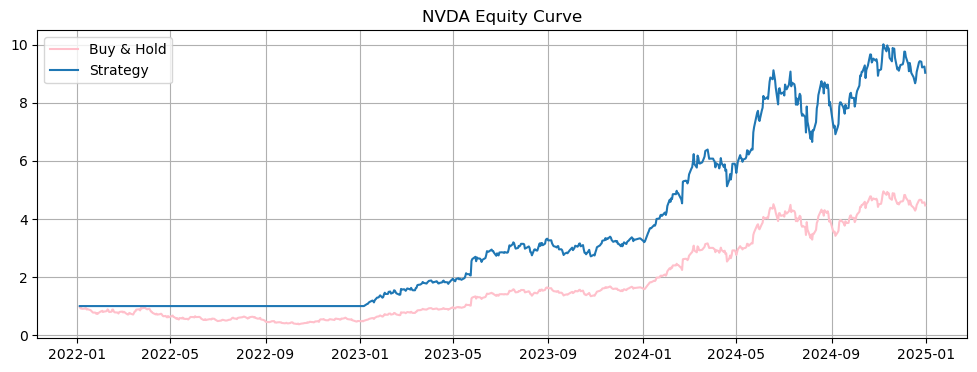

In [31]:
plot_equity_curve("NVDA", "2022-01-01", "2025-01-01", 50, 150)

### Interpretation

The strategy performed particularly well for NVIDIA during the out-of-sample period, generating substantially higher returns than a buy-and-hold approach while experiencing a smaller maximum drawdown.

One possible explanation is that the strategy benefited from NVIDIA's strong and sustained upward trend during the AI-driven market expansion of 2023–2025. Trend-following strategies such as moving average crossovers generally perform best when markets exhibit persistent directional movements.

However, it is important to note that this period may represent unusually favourable market conditions. Strong performance in a single asset and time period does not guarantee similar results in future market environments.

This highlights the importance of testing strategies across multiple assets and market regimes before drawing firm conclusions.

## Conclusions

This project investigated whether a moving average crossover strategy could outperform a buy-and-hold approach after transaction costs.

The results demonstrated that performance varied significantly across assets. While several securities underperformed buy-and-hold, others produced strong out-of-sample results with improved risk-adjusted returns and reduced drawdowns.

The train-test framework proved valuable in identifying strategies that remained effective on unseen data, helping to reduce the risk of overfitting.

The introduction of the Robust Score provided a simple method of combining out-of-sample performance with consistency between training and testing periods.

Overall, the project highlights both the potential and limitations of trend-following strategies and demonstrates the importance of rigorous testing when evaluating systematic trading rules.

## Limitations
- Daily data only.
- Long-only positions.
- No slippage modelling.
- Limited parameter search space.
- Custom robustness metric.
- Does not account for portfolio construction or diversification.

## Future Improvements
- Walk-forward optimisation.
- Additional technical indicators.
- Volatility targeting.
- Portfolio-level backtesting.
- Comparison with alternative trend-following methods.